<a href="https://colab.research.google.com/github/Giuseppe86-lab/Software_anti-spam_per_universita/blob/main/Filtro_AntiSpam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROGETTO SPAM DETECTION
L'azienda ProfessionAI vuole realizzare una libreria capace di fare analisi delle email ricevute.
Nello specifico, il CEO ha richiesto di identificare le email di tipo SPAM sulle quali fare analisi contenutistiche.
Il CTO nello specifico ti fornisce un dataset e ti chiede di:
- Addestrare un classificatore per identificare SPAM
- Individuare i Topic principali tra le email SPAM presenti nel dataset
- Calcolare la distanza semantica tra i topics ottenuti, per dedurne l'eterogeneità.
- Estrarre dalle mail NON SPAM le Organizzazioni presenti.

# 0 Utils e preparazione dell'ambiente

##0.1 Setup

In [ ]:
# 🛠️ SETUP AMBIENTE - Installa versioni compatibili
!pip install tensorflow==2.12.0 keras==2.12.0 numpy==1.23.5 --quiet
!pip install seaborn scipy gensim spacy nltk matplotlib --quiet
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 9.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.7 which is incompatible.
xarray 2

##0.2 Import Librerie

In [ ]:
#Libreria per la manipolazione dei dati
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import json

#Preprocessing e valutazione
import re
import string
import spacy
import nltk
from nltk.corpus import stopwords
from scipy.stats import ks_2samp

#Libreria NLP
import gensim
from gensim.models import Word2Vec
import gensim.downloader as api
from gensim.utils import simple_preprocess

#Classificatore
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

##0.3 Definizione funzione clean_text(text)

In [ ]:
nltk.download('stopwords')
english_stopwords = stopwords.words('english')
nlp = spacy.load('en_core_web_sm')
punctuation = set(string.punctuation)

def clean_text(text):
  text = text.lower()
  # Rimuovi URL ed email
  text = re.sub(r"http\S+|www\S+|https\S+", '', text)
  text = re.sub(r"\S+@\S+", '', text)

  # Riduci lettere ripetute (es. noooo -> no)
  text = re.sub(r'(.)\1{2,}', r'\1', text)
  for c in punctuation:
    text = text.replace(c, ' ') #rimuovere punteggiatura

  document = nlp(text)
  text = ' '.join(token.lemma_ for token in document)
  text = ' '.join(word for word in text.split() if word not in english_stopwords) #rimuovere stopwords
  text = re.sub(r'\d+', '', text) #rimuovere numeri
  text = re.sub(" +", " ", text)
  text = re.sub(r"[^a-z\s]", "", text) #rimuovere caratteri non alfabetici

  return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


##0.4 Definizione get_document_vector(doc, model)

In [ ]:
# Carica il modello GloVe pre-addestrato
glove_vector = api.load('glove-wiki-gigaword-300')  # modello con 300 dimensioni
def get_document_vector(doc, model):
    tokens = clean_text(doc).split()
    # Ottieni il vettore per ogni parola se esiste nel modello
    word_vectors = [model[word] for word in tokens if word in model]

    if len(word_vectors) == 0:  # Se nessuna parola è presente nel modello, usa un vettore nullo
        return np.zeros(model.vector_size)

    # Calcola la media dei vettori delle parole nel documento
    return np.mean(word_vectors, axis=0)

[==================================================] 100.0% 376.1/376.1MB downloaded


##0.5 Definizione funzioni, classi e metodi per i Classificatori

In [ ]:
class BaseClassifier:
  """
  This Class defines the operations that can be done to create and analyze the
  ML model, this is a BaseClass that can be adapted for any model.
  """
  def __init__(self, model, threshold = 0.5):
    """
    Initialize the BaseClassifier instance.

    Methods:
    - fit(self, X, y)
    - predict_proba(self, X)
    - predict(self, y_probs, threshold = None)
    - find_best_th_C(self, X, y, metric=f1_score)
    - create_report(self, X, y)
    - plot_confusion_matrix(self, X, y, labels=["No Spam", "Spam"], show_precision_recall=False)


    Arguments:
    - model: create the model.
    - threshold (float): threshold between 0 and 1.
    """
    self.model = model
    self.threshold = threshold
    self.report = None

  def fit(self, X, y):
      self.model.fit(X, y)

  def predict_proba(self, X):
    try:
      #scikit-learn
      return self.model.predict_proba(X)[:,1]
    except AttributeError:
      #TensorFlow
      return self.model.predict(X).ravel()

  def predict(self, X, threshold=None):
      threshold = threshold if threshold is not None else self.threshold
      proba = self.predict_proba(X)
      return (proba >= threshold).astype(int)

  def find_best_threshold(self, X, y, metric=f1_score):
      y_scores = self.predict_proba(X)
      thresholds = np.linspace(0.1, 0.9, 81)
      best_thresh = 0.5
      best_score = -1

      for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = metric(y, y_pred)
        if score > best_score:
          best_score = score
          best_thresh = thresh

      self.threshold = best_thresh
      print(f"Best threshold by {metric.__name__}: {best_thresh:.2f} - {best_score:.2f}")
      return best_thresh, best_score

  def create_report(self, X, y):
      y_pred = self.predict(X)
      self.report = classification_report(y, y_pred)
      print(self.report)
      return self.report

  def plot_confusion_matrix(self, X, y, labels=["No Spam", "Spam"], show_precision_recall=False):
      y_pred = self.predict(X)
      cm = confusion_matrix(y, y_pred)
      df_cm = pd.DataFrame(cm, index=labels, columns=["Predicted " + label for label in labels])
      sns.heatmap(df_cm, annot=True, fmt='g')
      if show_precision_recall:
        precision = cm[1][1] / (cm[0][1] + cm[1][1]) if (cm[0][1] + cm[1][1]) > 0 else 0
        recall = cm[1][1] / (cm[1][0] + cm[1][1]) if (cm[1][0] + cm[1][1]) > 0 else 0
        plt.text(0, -0.1, f"Precision: {precision:.3f}")
        plt.text(1, -0.1, f"Recall: {recall:.3f}")
      plt.show()

In [ ]:
def build_mlp_model(input_dim, hidden_units=64, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(Dense(hidden_units, activation='relu', input_dim=input_dim))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])
    return model

In [ ]:
class LogisticRegressionClassifier(BaseClassifier):
  def __init__(self, **kwargs):
    model = LogisticRegression(**kwargs)
    super().__init__(model)

class MLPModel(BaseClassifier):
    def __init__(self, input_dim, hidden_units=64, dropout_rate=0.3, learning_rate=0.001, threshold=0.5):
        model = build_mlp_model(input_dim, hidden_units, dropout_rate, learning_rate)
        super().__init__(model, threshold)

    def fit(self, X, y, epochs=10, batch_size=32, verbose=1):
        self.model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=verbose)
        return super().fit(X, y)

#1 Caricamento Dataset

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ProfAI/natural-language-processing/refs/heads/main/datasets/Verifica%20Finale%20-%20Spam%20Detection/spam_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


In [ ]:
df.shape

(5171, 4)

In questo dataset abbiamo 5171 mail. Le colonne che ci interessano sono:
- **text**: dove è presente il testo della mail da classificare;
- **label_num**: che rappresenta la nostra variabile target dove 0 vuol dire no spam e 1 no spam.
Le altre due colonne, dalla documentazione in nostro possesso, non sono informative, quindi le possiamo scartare.

In [ ]:
df = df[['text','label_num']]
df.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\nth...,0
1,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\nthis deal is to ...,0


Controlliamo che non ci siano righe duplicate:

In [ ]:
duplicati = df.duplicated().sum()
print(f'Numero di righe duplicate (testo e label identici): {duplicati}')

duplicati_mail = df.duplicated(subset=['text']).sum()
print(f'Numero di mail duplicate: {duplicati_mail}')

Numero di righe duplicate (testo e label identici): 178
Numero di mail duplicate: 178


I questo dataset ci sono 178 righe duplicate che possiamo eliminare:

In [ ]:
# Rimuove i duplicati
df = df.drop_duplicates(subset=["text", "label_num"]).reset_index(drop=True)
print(f"Nuova dimensione del dataset: {df.shape}")

Nuova dimensione del dataset: (4993, 2)


Verifichiamo che non ci siano mail senza etichetta:

In [ ]:
print(df["label_num"].unique())

[0 1]


Questo risultato ci dice che non sono presenti altre etichette oltre allo 0 e 1, quindi non ci sono mail senza etichette.

#2 Analisi Esplorativa dei Dati (EDA)

In questa fase investigheremo:
- La distribuzione di Spam/NoSpam nel dataset
- Se c'è una dipendenza tra la lunghezza del testo e l'etichetta


 Distribuzione delle mail:
label_num
0    3531
1    1462
Name: count, dtype: int64


<ipython-input-12-6aa6f4bfc7ed>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')


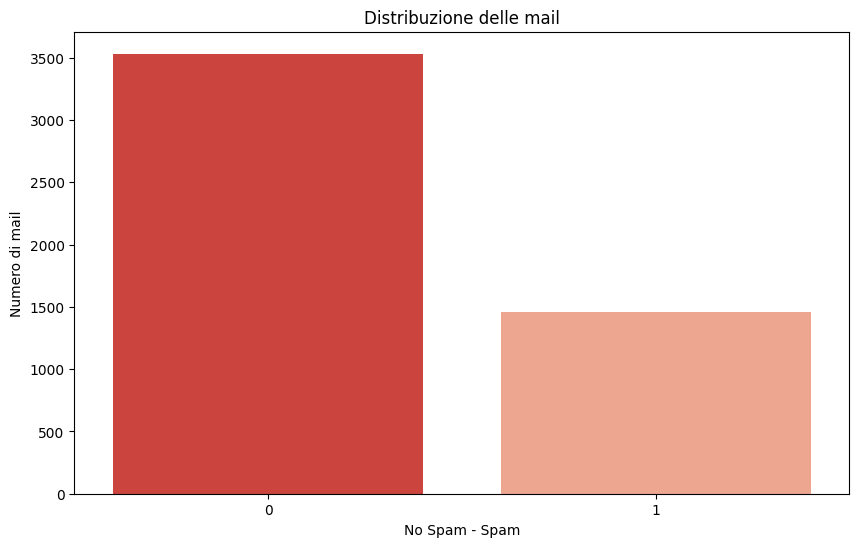

In [ ]:
# Somma delle etichette per categoria
label_counts = df["label_num"].value_counts().sort_values(ascending=False)
print('\n Distribuzione delle mail:')
print(label_counts)

#Grafico distribuzione delle etichette
plt.figure(figsize=(10,6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')
plt.title('Distribuzione delle mail')
plt.ylabel('Numero di mail')
plt.xlabel('No Spam - Spam')
plt.show()

Il dataset è sbilanciato anche se le mail di spam sono circa il 30%, che potrebbe essere una percentuale sufficiente per creare un classificatore con buona performance, senza dover eseguire dell'oversampling/undersampling sul campione di training.

Studiamo la lunghezza del testo delle mail rispetto all'etichetta.

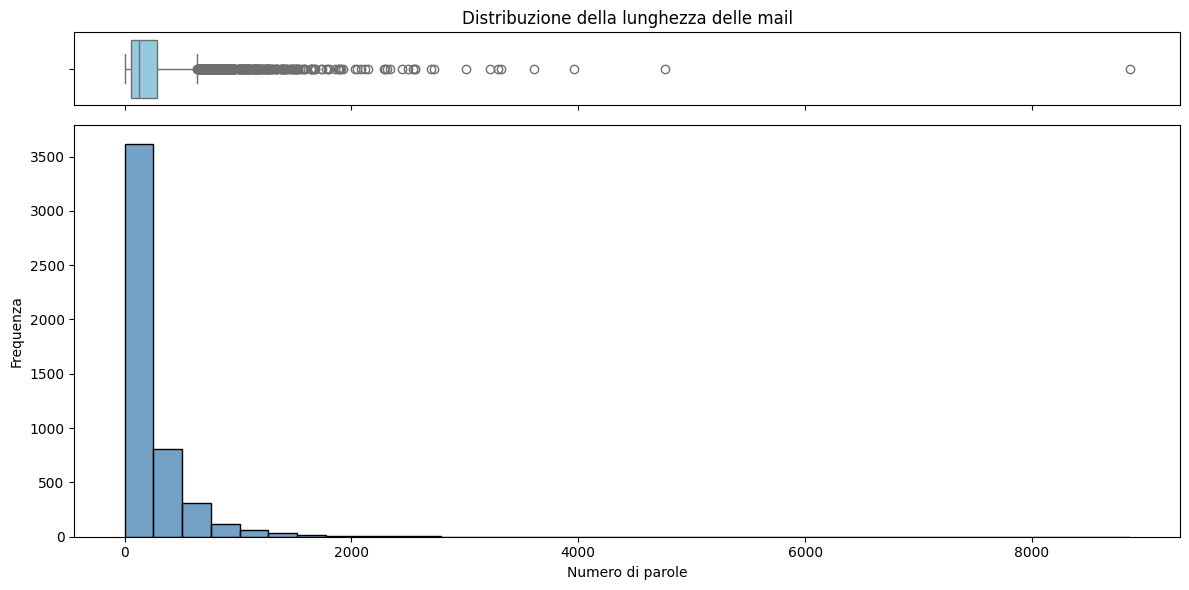

In [ ]:
#Aggiungo una colonna con la lunghezza di ciascuna mail
df['mail_length'] = df['text'].str.split().apply(len)

#Istogramma e boxplor della lughezza delle mail
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize = (12, 6), sharex = True,
                                      gridspec_kw={"height_ratios": (0.15, 0.85)})

sns.boxplot(x=df['mail_length'], ax = ax_box, color = 'skyblue')
ax_box.set(xlabel='')
ax_box.set_title('Distribuzione della lunghezza delle mail')

sns.histplot(df['mail_length'], bins='rice', ax = ax_hist, color = 'steelblue')
ax_hist.set_xlabel('Numero di parole')
ax_hist.set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

Vediamo che la maggior parte delle mail hanno una lunghezza minore di 2000 parole ma entrambi i grafici presentano degli outlier con commenti anche con oltre 8000 parole, vediamo se queste distribuzioni sono sensibili alla tipologia delle mail.

<ipython-input-14-dba366f4a892>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='mail_length', ax=axes[1], palette='Set2')


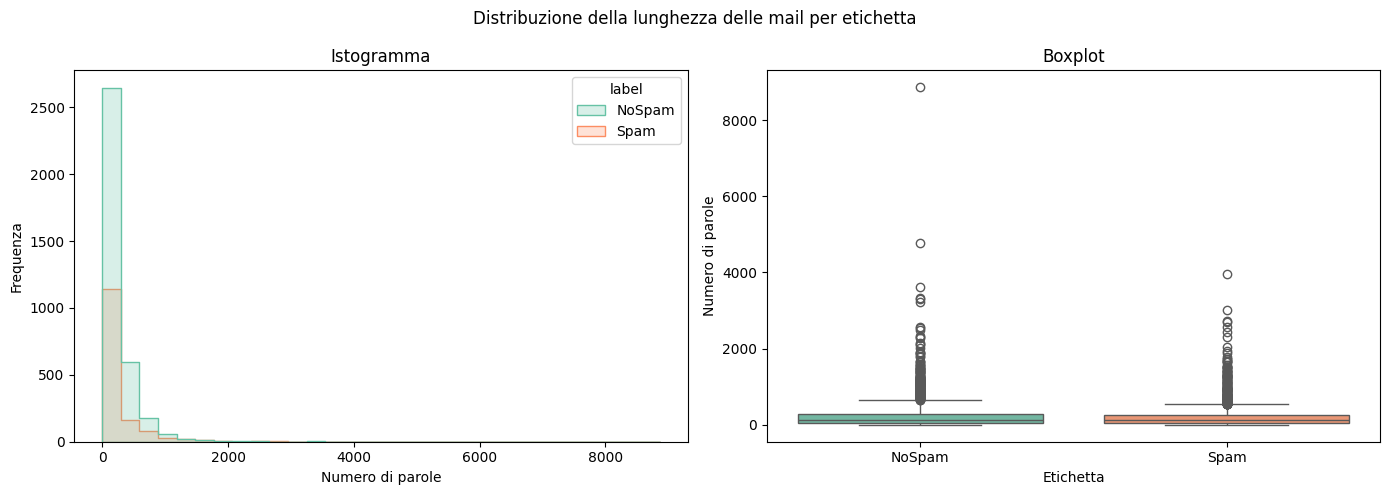

In [ ]:
# Mappa numeri a etichette per leggibilità nei grafici
df['label'] = df['label_num'].map({0: 'NoSpam', 1: 'Spam'})

# Crea figura con due grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuzione della lunghezza delle mail per etichetta")

# Istogramma sovrapposto
sns.histplot(data=df, x='mail_length', hue='label', bins=30, kde=False, ax=axes[0], palette='Set2', element='step')
axes[0].set_title('Istogramma')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')

# Boxplot
sns.boxplot(data=df, x='label', y='mail_length', ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot')
axes[1].set_xlabel('Etichetta')
axes[1].set_ylabel('Numero di parole')

plt.tight_layout()
plt.show()

La distribuzione delle lunghezze delle mail non sembra dipendere dal tipo di mail ma verifichiamo anche con il Mann-Whitney U test in quanto le distribuzioni non verificano l'ipotesi di normalità, quindi un t-test potrebbe dare risultati non adeguati. In questo test l'ipotesi H0 è che i due campioni provengano dalla stessa distribuzione.

In [ ]:
group1 = df[df['label_num'] == 0]['mail_length']
group2 = df[df['label_num'] == 1]['mail_length']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
print(f"mail_length: Mann-Whitney U Test: p-value = {p_value}")

if p_value < 0.05:
    print(f"mail_length dipende significativamente da label_num.\n")
else:
    print(f"Non c'è evidenza che mail_length dipenda da label_num.\n")

mail_length: Mann-Whitney U Test: p-value = 0.42103537044103656
Non c'è evidenza che mail_length dipenda da label_num.



Il risultato del test conferma che non c'è evidenza che la in numero di parole nelle mail dipenda dall'etichetta.

#3 Pulizia del testo, embedding del testo, splitting
Prepariamo il testo per poter essere usato come input per il nostro classificatore.

Usiamo le due funzioni:
- clean_text: elimina indirizzi mail, URL, riduce le lettere ripeture, rimuove la punteggiatura, lemmizza le parole, rimuove le stopwords, elimina numeri, caratteri non alfabetici e spazi multipli.
- get_document_vector: che chiamando la funzione clean_text() restituisce un vettore con la media delle parole del documento.


Dopo procederemo con la suddivisione del dataset in train, test e validation


In [ ]:
# Ottieni il vettore per ciascun documento
document_vectors = [get_document_vector(text, glove_vector) for text in df['text']]

In [ ]:
# Converto la lista di vettori in un array numpy
X = np.array(document_vectors)
y = df['label_num'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=df['label_num'], random_state=42)


Verifichiamo che X_train e X_test siano campioni rappresentativi del dataset, cioè che abbiano le stesse caratteristiche, per questo scopo usiamo il test di Kolmogorov-Smirnov:

In [ ]:
stat, p_value = ks_2samp(X_train.flatten(), X.flatten())

print("Verifica distribuzione per X_train")
print(f"Statistiche K-S: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Rifiutiamo l'ipotesi nulla: le distribuzioni sono diverse.\n")
else:
    print("Non rifiutiamo l'ipotesi nulla: le distribuzioni sono uguali.\n")


stat, p_value = ks_2samp(X_test.flatten(), X.flatten())
print("\nVerifica distribuzione per X_test")
print(f"Statistiche K-S: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Rifiutiamo l'ipotesi nulla: le distribuzioni sono diverse.\n")
else:
    print("Non rifiutiamo l'ipotesi nulla: le distribuzioni sono uguali.\n")

Verifica distribuzione per X_train
Statistiche K-S: 0.0010
P-value: 0.5143
Non rifiutiamo l'ipotesi nulla: le distribuzioni sono uguali.


Verifica distribuzione per X_test
Statistiche K-S: 0.0024
P-value: 0.0336
Rifiutiamo l'ipotesi nulla: le distribuzioni sono diverse.



#4 Classificatore: Costruzione Modelli

##4.1 Modello Baseline: Regressione Logistica
Usiamo un modello semplice per definire una baseline nella classificazione di mail SPAM/NOSPAM

In [ ]:
ss = StandardScaler()
X_train_LR = ss.fit_transform(X_train)
X_test_LR = ss.transform(X_test)

FINE TUNING DEGLI IPERPARAMETRI: RICERCA SOGLIA OTTIMALE
Best threshold by f1_score: 0.47
-----------------------------------

 REPORT METRICHE - TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2472
           1       0.99      1.00      1.00      1023

    accuracy                           1.00      3495
   macro avg       1.00      1.00      1.00      3495
weighted avg       1.00      1.00      1.00      3495

-----------------------------------
Confusion Matrix Train


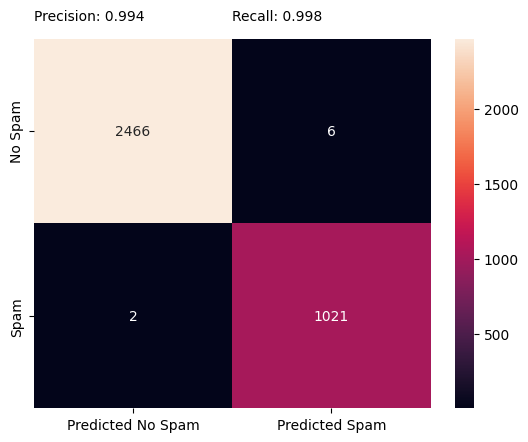

In [ ]:
clf_lr = LogisticRegressionClassifier()
clf_lr.fit(X_train_LR, y_train)

print('FINE TUNING DEGLI IPERPARAMETRI: RICERCA SOGLIA OTTIMALE')
clf_lr.find_best_threshold(X_train_LR, y_train)

print('-----------------------------------')

print(f'\n REPORT METRICHE - TRAIN')
clf_lr.create_report(X_train_LR, y_train)

print('-----------------------------------')
print('Confusion Matrix Train')
clf_lr.plot_confusion_matrix(X_train_LR, y_train, show_precision_recall=True)

Vediamo come il modello ha delle ottime performance anche se la cross validation presenta dei rischi di overfitting.

Confusion Matrix Test Modello 1


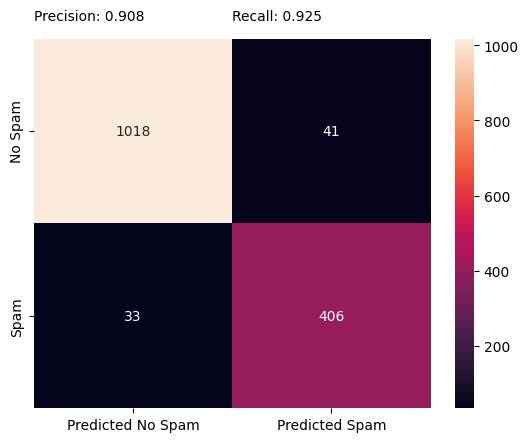

In [ ]:
print('Confusion Matrix Test Modello 1')
clf_lr.plot_confusion_matrix(X_test_LR, y_test, show_precision_recall=True)

Precision e Recall sono passati dal 99% al 91% e 93% rispettivamente, ottimi risultati per un modello semplice come la regressione logistica. Proveremo se con un MLP otterremo risultati migliori.

##4.2 Modello MLP

Epoch 1/10
110/110 [==============================] - 1s 2ms/step - loss: 0.3727 - accuracy: 0.8435
Epoch 2/10
110/110 [==============================] - 0s 2ms/step - loss: 0.1760 - accuracy: 0.9365
Epoch 3/10
110/110 [==============================] - 0s 2ms/step - loss: 0.1300 - accuracy: 0.9534
Epoch 4/10
110/110 [==============================] - 0s 2ms/step - loss: 0.1108 - accuracy: 0.9631
Epoch 5/10
110/110 [==============================] - 0s 2ms/step - loss: 0.0957 - accuracy: 0.9677
Epoch 6/10
110/110 [==============================] - 0s 2ms/step - loss: 0.0864 - accuracy: 0.9700
Epoch 7/10
110/110 [==============================] - 0s 2ms/step - loss: 0.0803 - accuracy: 0.9740
Epoch 8/10
110/110 [==============================] - 0s 2ms/step - loss: 0.0744 - accuracy: 0.9754
Epoch 9/10
110/110 [==============================] - 0s 2ms/step - loss: 0.0686 - accuracy: 0.9751
Epoch 10/10
110/110 [==============================] - 1s 5ms/step - loss: 0.0592 - accuracy: 0.9803

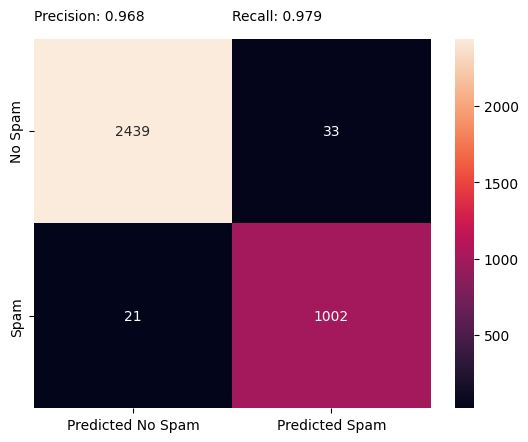


 REPORT METRICHE - TEST:
47/47 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1059
           1       0.92      0.95      0.94       439

    accuracy                           0.96      1498
   macro avg       0.95      0.96      0.95      1498
weighted avg       0.96      0.96      0.96      1498

-----------------------------------
Confusion Matrix Test
47/47 [==============================] - 0s 2ms/step


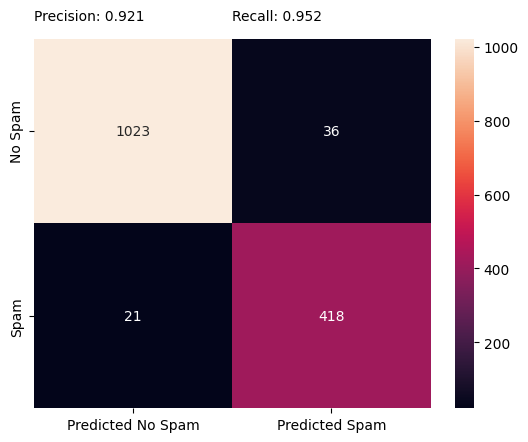

In [ ]:
clf = MLPModel(input_dim=X_train.shape[1], hidden_units=64, dropout_rate=0.3, learning_rate=0.001)
clf.fit(X_train, y_train)

print('FINE TUNING DEGLI IPERPARAMETRI: RICERCA SOGLIA OTTIMALE')
clf.find_best_threshold(X_train, y_train)

print('-----------------------------------')

print(f'\n REPORT METRICHE - TRAIN:')
clf.create_report(X_train, y_train)

print('-----------------------------------')
print('Confusion Matrix Train')
clf.plot_confusion_matrix(X_train, y_train, show_precision_recall=True)

print(f'\n REPORT METRICHE - TEST:')
clf.create_report(X_test, y_test)

print('-----------------------------------')
print('Confusion Matrix Test')
clf.plot_confusion_matrix(X_test, y_test, show_precision_recall=True)

Possiamo osservare che questo modello soffre meno di overfitting e ha metriche migliori per quando riguardo il dataset di test: ottenendo il 92% di precisione e il 95% in recall. Testiamo il modello su tutto il dataset:

## 4.2 Analisi MLP sull'intero dataset


 REPORT METRICHE:
157/157 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3531
           1       0.95      0.97      0.96      1462

    accuracy                           0.98      4993
   macro avg       0.97      0.98      0.97      4993
weighted avg       0.98      0.98      0.98      4993

-----------------------------------
Confusion Matrix
157/157 [==============================] - 0s 1ms/step


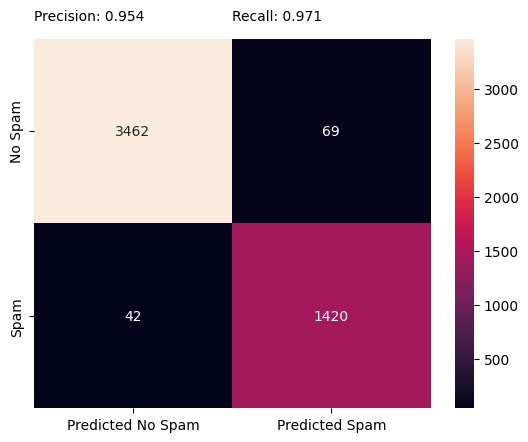

In [ ]:
print(f'\n REPORT METRICHE:')
clf.create_report(X, y)

print('-----------------------------------')
print('Confusion Matrix')
clf.plot_confusion_matrix(X, y, show_precision_recall=True)

Le performance risultano ottimali, quindi il nostro modello è in grado di distinguire tra mail di spam: la percentuale di mail etichettate in modo errato è il: 2,3%.

#5 Individuare i topic principali email SPAM

In questa seconda parte del progetto dobbiamo andare ad individuare gli argomenti principali trattati nelle email classificate come SPAM.

Per questo compito come per i successivi faremo un preprocessing del testo, meno invasivo di quello usato per la classificazione delle mail.

In [ ]:
def sent_to_words(items):
  for item in items:
    yield(simple_preprocess(item, deacc=True))

def remove_stopwords(texts):
  return [[word for word in words if word not in english_stopwords and len(word)>=5] for words in texts]

In [ ]:
df_spam = df[df['label_num'] == 1]
df_spam.head()

,text,label_num,mail_length
3,"Subject: photoshop , windows , office . cheap ...",1,48
7,Subject: looking for medication ? we ` re the ...,1,164
10,Subject: vocable % rnd - word asceticism\nvcsc...,1,1203
11,Subject: report 01405 !\nwffur attion brom est...,1,71
13,Subject: vic . odin n ^ ow\nberne hotbox carna...,1,51


In [ ]:
documents_spam = df_spam['text']

In [ ]:
data_words = list(sent_to_words(documents_spam))
data_words = remove_stopwords(data_words)

In [ ]:
import gensim.corpora as corpora
id2word = corpora.Dictionary(data_words)
corpus = [id2word.doc2bow(text) for text in data_words]

In [ ]:
from pprint import pprint
num_topics = 5
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics,
                                       passes = 10)
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.022*"subject" + 0.007*"please" + 0.006*"email" + 0.005*"message" + '
  '0.005*"computron" + 0.005*"contact" + 0.005*"click" + 0.005*"money" + '
  '0.004*"online" + 0.004*"account"'),
 (1,
  '0.014*"company" + 0.010*"statements" + 0.007*"information" + 0.006*"within" '
  '+ 0.006*"stock" + 0.005*"report" + 0.005*"securities" + 0.005*"investment" '
  '+ 0.004*"looking" + 0.004*"price"'),
 (2,
  '0.016*"height" + 0.014*"width" + 0.009*"align" + 0.009*"border" + '
  '0.006*"center" + 0.005*"bgcolor" + 0.005*"subject" + 0.004*"index" + '
  '0.004*"color" + 0.003*"style"'),
 (3,
  '0.011*"pills" + 0.010*"subject" + 0.007*"price" + 0.007*"windows" + '
  '0.006*"adobe" + 0.005*"microsoft" + 0.005*"professional" + 0.005*"office" + '
  '0.004*"software" + 0.004*"cialis"'),
 (4,
  '0.007*"subject" + 0.003*"family" + 0.003*"style" + 0.002*"normally" + '
  '0.002*"valign" + 0.002*"height" + 0.002*"epson" + 0.002*"artprice" + '
  '0.001*"content" + 0.001*"email"')]


# 6 Distanza semantica tra i topic ottenuti
Per determinare la distanza semantica tra i topic voglio creare un vettore formato da 5 elementi: ogni elemento è un vettore con le parole del topic.

Da questo calcolerò il vettore medio per ogni topic, considerando anche i pesi di ogni parola. Questi vettori medi saranno quelli che usero per determinare la distanza semantica tra i topic.

In [ ]:
# Numero di topic
num_topics = lda_model.num_topics
topic_vectors = {}
# Parole rappresentative per ciascun topic
for i in range(num_topics):
    vectors = []
    weights = []
    topic_words = lda_model.show_topic(i, topn=10)  # restituisce [(word1, weight1), (word2, weight2), ...]
    for word, weight in topic_words:
        vectors.append(word)
        weights.append(weight)
  #  words_only = [word for word, weight in topic_words]
        sentence = " ".join(vectors)
    print(f"Topic {i}: {sentence}")
    topic_vectors[f'Topic_{i}']={'topic_sentence': vectors, 'weights': weights}

print(topic_vectors)

Topic 0: subject please email message computron contact click money online account
Topic 1: company statements information within stock report securities investment looking price
Topic 2: height width align border center bgcolor subject index color style
Topic 3: pills subject price windows adobe microsoft professional office software cialis
Topic 4: subject family style normally valign height epson artprice content email
{'Topic_0': {'topic_sentence': ['subject', 'please', 'email', 'message', 'computron', 'contact', 'click', 'money', 'online', 'account'], 'weights': [0.022059485, 0.006853683, 0.006089133, 0.0053880927, 0.005360601, 0.0047972654, 0.004749646, 0.0046725376, 0.0041196444, 0.00384365]}, 'Topic_1': {'topic_sentence': ['company', 'statements', 'information', 'within', 'stock', 'report', 'securities', 'investment', 'looking', 'price'], 'weights': [0.01357794, 0.009667239, 0.0065436843, 0.0055681174, 0.0055361693, 0.0053941, 0.0053153983, 0.0051107593, 0.003877178, 0.00385199

In [ ]:
def avg_weighted_vector(sentence, weight):
  vector = np.zeros(300)
  total_weight = 0
  for i, word in enumerate(sentence):
    if word in glove_vector.key_to_index.keys():
      vector = vector + glove_vector[word] * weight[i]
      total_weight += weight[i]

  if total_weight == 0:
    return np.zeros(300)

  return vector / total_weight

In [ ]:
from scipy.spatial.distance import cosine

def cosine_similarity(vector1, vector2): #funzione per determinare la distanza semantica
  return 1 - cosine(vector1, vector2)

La funzione create_radar_plot() serve per generare gli spider plot per confrontare le distanze semantiche tra i vari topic.

In [ ]:
def create_radar_plot(topic_index, cosine_similarities, num_topics=5):
    labels = []
    values = []

    for i in range(num_topics):
        if i == topic_index:
            continue  # salta il confronto con se stesso
        key = f'Topic_{topic_index}-Topic_{i}'
        reverse_key = f'Topic_{i}-Topic_{topic_index}'
        sim = cosine_similarities.get(key) or cosine_similarities.get(reverse_key)
        if sim is not None:
            labels.append(f'Topic_{i}')
            values.append(sim)

    # Chiudi il cerchio per il radar plot
    labels.append(labels[0])
    values.append(values[0])

    angles = np.linspace(0, 2 * np.pi, len(labels)-1, endpoint=False).tolist()
    angles.append(angles[0])

    fig, ax = plt.subplots(figsize=(3, 3), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=2, linestyle='solid')
    ax.fill(angles, values, alpha=0.4)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color="grey", size=8)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_title(f'Radar Plot - Topic {topic_index}', size=14, pad=20)

    return fig

Determino il vettore medio per ogni topic pesato sui pesi delle parole individuate dal topic.

In [ ]:
weighted_vectors = {}
for topic, values in topic_vectors.items():
  weighted_vectors[topic] = avg_weighted_vector(values['topic_sentence'], values['weights'])

Cosine similarity between Topic_0 and Topic_1: 0.56
Cosine similarity between Topic_0 and Topic_2: 0.27
Cosine similarity between Topic_0 and Topic_3: 0.55
Cosine similarity between Topic_0 and Topic_4: 0.75
Cosine similarity between Topic_1 and Topic_0: 0.56
Cosine similarity between Topic_1 and Topic_2: 0.24
Cosine similarity between Topic_1 and Topic_3: 0.57
Cosine similarity between Topic_1 and Topic_4: 0.51
Cosine similarity between Topic_2 and Topic_0: 0.27
Cosine similarity between Topic_2 and Topic_1: 0.24
Cosine similarity between Topic_2 and Topic_3: 0.28
Cosine similarity between Topic_2 and Topic_4: 0.55
Cosine similarity between Topic_3 and Topic_0: 0.55
Cosine similarity between Topic_3 and Topic_1: 0.57
Cosine similarity between Topic_3 and Topic_2: 0.28
Cosine similarity between Topic_3 and Topic_4: 0.56
Cosine similarity between Topic_4 and Topic_0: 0.75
Cosine similarity between Topic_4 and Topic_1: 0.51
Cosine similarity between Topic_4 and Topic_2: 0.55
Cosine simil

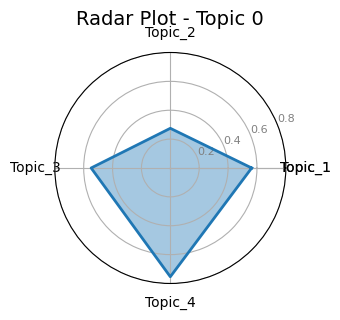

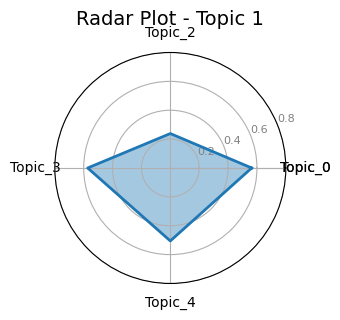

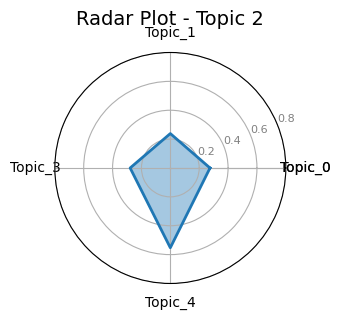

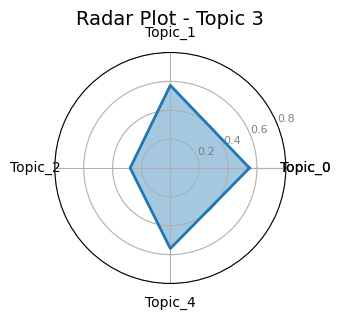

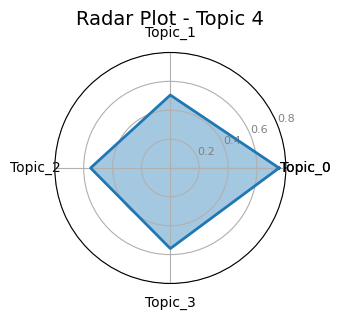

In [ ]:
cosine_similarities = {}
for topic1, vector1 in weighted_vectors.items():
  for topic2, vector2 in weighted_vectors.items():
    if topic1 != topic2:
      similarity = cosine_similarity(vector1, vector2)
      cosine_similarities[f'{topic1}-{topic2}'] = similarity
      print(f"Cosine similarity between {topic1} and {topic2}: {similarity:.2f}")

figs = []
for topic_index in range(num_topics):
  fig = create_radar_plot(topic_index, cosine_similarities)
  figs.append(fig)

plt.show()

Facciamo uno schema dei topic che risultano più simili:
- Topic_0 - Topic_4: 0.75
- Topic_1 - Topic_3: 0.57
- Topic_2 - Topic_4: 0.55
- Topic_3 - Topic_1: 0.57
- Topic_4 - Topic_0: 0.75

Possiamo osservare come gli unici topic che risultano simili sono lo 0 e il 4, gli altri mostrano una buona etereogeneità. Segno che l'algoritmo ha colto i topic delle mail di spam.

I diagrammi a radar mostrano in modo evidente che i topic che hanno un'area maggiore sono il topic 0 e il topic 4, maggiore similarità, il topic 2 invece si mostra come il quello con l'area di similarità più piccola.

#7 Estrarre le Organizzazioni dalle mail NON SPAM

Anche in questo caso definiamo una light_clean() perché un cleaning più massiccio potrebbe eliminare informazioni importanti per individuare le organizzazioni.

In [ ]:
#Per l'analisi NER è consigliabile pulire il testo non in modo massiccio
def light_clean(text):
    for c in punctuation:
      text = text.replace(c, ' ') #rimuovere punteggiatura
    text = re.sub(r'\s+', ' ', text)  # rimuove spazi multipli
    return text.strip()

La funzione find_organizzation() cerca le organizzazioni nelle frasi, ma raggruppa insieme token prossimali etichettati come ORG. Questo serve per individuare organizzazioni con un nome formato da più token.

In [ ]:
def find_organizzation(sentence):
  org_vector = []
  doc = nlp(sentence)
  i=0
  while i < len(doc):
    if doc[i].ent_type_ == 'ORG':
      org_tokens = [doc[i].text]
      i += 1
      while i < len(doc) and doc[i].ent_type_ == 'ORG':
        org_tokens.append(doc[i].text)
        i += 1
      org_vector.append(' '.join(org_tokens))
    else:
        i += 1
  return org_vector

Questa funzione serve per fare una pulizia di token individuati erroneamente come organizzazioni.

In [ ]:
def is_valid_org(org):
    if len(org) < 3:
        return False
    if org.lower() in {"corp", "hou", "north", "pat", "ect", "subject", "doc", "inc"}:  # black list
        return False
    if any(char in org for char in {'\x01', '@', ':', '.', ','}):
        return False
    return True


In [ ]:
df_nospam = df[df['label_num'] == 0].copy()
df_nospam['text'] = df_nospam['text'].apply(light_clean)

In [ ]:
df_nospam['organizzation']=df_nospam['text'].apply(find_organizzation)

In [ ]:
df_nospam.head()

,text,label_num,mail_length,organizzation
0,Subject enron methanol meter 988291 this is a ...,0,67,[]
1,Subject hpl nom for january 9 2001 see attache...,0,23,[]
2,Subject neon retreat ho ho ho we re around to ...,0,550,[]
4,Subject re indian springs this deal is to book...,0,70,[]
5,Subject ehronline web address change this mess...,0,98,[]


In [ ]:
from collections import Counter
from itertools import chain

# Appiattiamo tutte le liste in un'unica lista
all_orgs = list(chain.from_iterable(df_nospam['organizzation']))
filtered_orgs = [org for org in all_orgs if is_valid_org(org)]

# Contiamo le occorrenze
org_counts = Counter(filtered_orgs)

# Mostriamo le N più comuni (ad esempio, le prime 10)
top_n = 10
for org, count in org_counts.most_common(top_n):
    print(f"{org}: {count}")


enron north america corp: 172
ami chokshi corp enron: 153
yahoo: 62
north america corp: 61
ect pat clynes corp enron: 46
tom acton corp enron: 44
texaco: 44
exxon: 42
ect pat clynes corp enron enron: 36
ferc: 28


Vediamo che enron compare sono diverse forme, conviene mettere un filtro. Enron è effettivamente una compagna americana, quindi possiamo unificare tutte le stringhe in cui compare Enron in un unico rappresentante.

In [ ]:
top_n = 20
count_enron = 0
for org, count in org_counts.most_common(top_n):
    if "enron" in org.lower():
        count_enron += count
    else:
      print(f"{org}: {count}")
print(f"Enron: {count_enron}")

yahoo: 62
north america corp: 61
texaco: 44
exxon: 42
ferc: 28
stella l morris hou: 28
stacey neuweiler: 27
chevron: 25
vance l: 22
ga 213: 22
pat clynes: 22
mobil: 22
morgan s point: 22
Enron: 502


Il risultato così è migliorato anche se permangono alcuni possibili nomi propri. Possiamo certamente dire che la compagnia Enron è la più presente nelle nostre mail.